# CapgMyo comparison

Select four random channels and compare with ENG

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import gc
gc.collect()

import sys
sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
import Model, utils, Same_with_MATLAB, Feature_info

import capgmyo_modules
f_path = 'C:/Users/hml76/Desktop/Jupyter/Datasets/CapgMyo/DB_B_preproceesed/'

In [2]:
def inter_session_run(idx, Feat_B):
    ACC_lst = []

    for SUB in range(1,11): #10
        print('Sub {}'.format(SUB))
        rep_lst = []
        X_train, y_train, X_test, y_test = [], [], [], []

        for rep in rep_lst_1:
            X, y = capgmyo_modules.import_dataset(subject=SUB, rep=rep, path=f_path, win_len=123, win_inc=24, sel_four_ch=idx, feature_selection=Feat_B)
            X_train.append(X)
            y_train.append(y)

        for rep in rep_lst_2:
            X, y = capgmyo_modules.import_dataset(subject=SUB, rep=rep, path=f_path, win_len=123, win_inc=24, sel_four_ch=idx, feature_selection=Feat_B)
            X_test.append(X)
            y_test.append(y)

        X_train, y_train = np.concatenate(X_train, axis=0), np.concatenate(y_train, axis=0)
        X_test, y_test = np.concatenate(X_test, axis=0), np.concatenate(y_test, axis=0)

        print(X_train.shape, X_test.shape)

        if Feat_B:  #2D-CNN: input: 16, 4
            X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
            X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)
            print(X_train.shape, X_test.shape)
            model = Model.Original_model(input_shape=X_train.shape[1:], num_class=8)

        else:
            X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
            X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
            print(X_train.shape, X_test.shape)
            model = Model.Original_model_1DCNN(input_size=X_train.shape[1:], num_class=8)

        history, model = Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=100, set_batch_size=128, Model_name='V0',
                                            set_verbose=False, save_model_set=False)
        acc = model.evaluate(X_test, y_test, verbose=0)[1]
        ACC_lst.append(acc)

    return ACC_lst

In [3]:
rep_lst_1 = [1,6] #random - for test / train => our ENG has only one session (20 reps each, but here it has 10 so we use two sessions)
rep_lst_2 = [4,8] #random - for test / train

In [4]:
idx = np.random.choice(128, size=4, replace=False)
acc_lst_ch4 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch4), np.mean(acc_lst_ch4)

Sub 1
(16000, 4) (16000, 4)
(16000, 4, 1) (16000, 4, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 24.64%
Maximum validation accuracy : 19.56%
Sub 2
(16000, 4) (16000, 4)
(16000, 4, 1) (16000, 4, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 29.09%
Maximum validation accuracy : 30.9%
Sub 3
(16000, 4) (16000, 4)
(16000, 4, 1) (16000, 4, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 24.97%
Maximum validation accuracy : 22.97%
Sub 4
(16000, 4) (16000, 4)
(16000, 4, 1) (16000, 4, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 23.04%
Maximum validation accuracy : 20.56%
Sub 5
(16000, 4) (16000, 4)
(16000, 4, 1) (16000, 4, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 24.39%
Maximum validation accuracy : 21.84%
Sub 6
(16000, 4) (16000, 4)
(16000, 4, 1) (16000, 4, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 21.75%
Maximum validation accuracy : 23.49%
Sub 7

(array([0.19562501, 0.30899999, 0.2296875 , 0.205625  , 0.218375  ,
        0.2349375 , 0.3084375 , 0.26449999, 0.26118749, 0.2344375 ]),
 np.float64(0.24618124663829805))

In [5]:
idx = np.random.choice(128, size=3, replace=False)
acc_lst_ch3 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch3), np.mean(acc_lst_ch3)

Sub 1
(16000, 3) (16000, 3)
(16000, 3, 1) (16000, 3, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 23.14%
Maximum validation accuracy : 19.86%
Sub 2
(16000, 3) (16000, 3)
(16000, 3, 1) (16000, 3, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 13.38%
Maximum validation accuracy : 13.96%
Sub 3
(16000, 3) (16000, 3)
(16000, 3, 1) (16000, 3, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 21.03%
Maximum validation accuracy : 19.74%
Sub 4
(16000, 3) (16000, 3)
(16000, 3, 1) (16000, 3, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 20.27%
Maximum validation accuracy : 19.87%
Sub 5
(16000, 3) (16000, 3)
(16000, 3, 1) (16000, 3, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 22.38%
Maximum validation accuracy : 21.63%
Sub 6
(16000, 3) (16000, 3)
(16000, 3, 1) (16000, 3, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 20.34%
Maximum validation accuracy : 20.84%
Sub 

(array([0.1985625 , 0.139625  , 0.197375  , 0.19868749, 0.2163125 ,
        0.2084375 , 0.20900001, 0.2003125 , 0.20118751, 0.2610625 ]),
 np.float64(0.20305625051259996))

In [6]:
idx = np.random.choice(128, size=2, replace=False)
acc_lst_ch2 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch2), np.mean(acc_lst_ch2)

Sub 1
(16000, 2) (16000, 2)
(16000, 2, 1) (16000, 2, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 21.64%
Maximum validation accuracy : 18.86%
Sub 2
(16000, 2) (16000, 2)
(16000, 2, 1) (16000, 2, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 22.72%
Maximum validation accuracy : 22.31%
Sub 3
(16000, 2) (16000, 2)
(16000, 2, 1) (16000, 2, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 24.91%
Maximum validation accuracy : 22.64%
Sub 4
(16000, 2) (16000, 2)
(16000, 2, 1) (16000, 2, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 25.19%
Maximum validation accuracy : 22.92%
Sub 5
(16000, 2) (16000, 2)
(16000, 2, 1) (16000, 2, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 22.69%
Maximum validation accuracy : 20.86%
Sub 6
(16000, 2) (16000, 2)
(16000, 2, 1) (16000, 2, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 19.12%
Maximum validation accuracy : 20.61%
Sub 

(array([0.18862499, 0.2230625 , 0.226375  , 0.2291875 , 0.208625  ,
        0.2060625 , 0.24662501, 0.201125  , 0.2278125 , 0.2533125 ]),
 np.float64(0.22108124941587448))

In [8]:
idx = np.random.choice(128, size=1, replace=False)
acc_lst_ch1 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch1), np.mean(acc_lst_ch1)

Sub 1
(16000, 1) (16000, 1)
(16000, 1, 1) (16000, 1, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 16.96%
Maximum validation accuracy : 16.79%
Sub 2
(16000, 1) (16000, 1)
(16000, 1, 1) (16000, 1, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 20.13%
Maximum validation accuracy : 16.73%
Sub 3
(16000, 1) (16000, 1)
(16000, 1, 1) (16000, 1, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 21.71%
Maximum validation accuracy : 21.24%
Sub 4
(16000, 1) (16000, 1)
(16000, 1, 1) (16000, 1, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 19.36%
Maximum validation accuracy : 19.18%
Sub 5
(16000, 1) (16000, 1)
(16000, 1, 1) (16000, 1, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 18.27%
Maximum validation accuracy : 16.69%
Sub 6
(16000, 1) (16000, 1)
(16000, 1, 1) (16000, 1, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 14.88%
Maximum validation accuracy : 16.99%
Sub 

(array([0.16787501, 0.16725001, 0.2124375 , 0.1918125 , 0.1669375 ,
        0.16993751, 0.2204375 , 0.1665    , 0.1646875 , 0.17524999]),
 np.float64(0.18031250089406967))

In [9]:
idx = np.random.choice(128, size=128, replace=False)
acc_lst_ch128 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch128), np.mean(acc_lst_ch128)

Sub 1
(16000, 128) (16000, 128)
(16000, 128, 1) (16000, 128, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.8%
Maximum validation accuracy : 12.5%
Sub 2
(16000, 128) (16000, 128)
(16000, 128, 1) (16000, 128, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 21.23%
Maximum validation accuracy : 26.24%
Sub 3
(16000, 128) (16000, 128)
(16000, 128, 1) (16000, 128, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.54%
Maximum validation accuracy : 12.5%
Sub 4
(16000, 128) (16000, 128)
(16000, 128, 1) (16000, 128, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.61%
Maximum validation accuracy : 12.5%
Sub 5
(16000, 128) (16000, 128)
(16000, 128, 1) (16000, 128, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 39.12%
Maximum validation accuracy : 40.76%
Sub 6
(16000, 128) (16000, 128)
(16000, 128, 1) (16000, 128, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 39.5

(array([0.125     , 0.262375  , 0.125     , 0.125     , 0.40762499,
        0.426875  , 0.625     , 0.125     , 0.125     , 0.125     ]),
 np.float64(0.24718749821186065))

In [10]:
idx = np.random.choice(128, size=120, replace=False)
acc_lst_ch120 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch120), np.mean(acc_lst_ch120)

Sub 1
(16000, 120) (16000, 120)
(16000, 120, 1) (16000, 120, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.55%
Maximum validation accuracy : 12.5%
Sub 2
(16000, 120) (16000, 120)
(16000, 120, 1) (16000, 120, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 45.53%
Maximum validation accuracy : 48.55%
Sub 3
(16000, 120) (16000, 120)
(16000, 120, 1) (16000, 120, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 49.81%
Maximum validation accuracy : 51.61%
Sub 4
(16000, 120) (16000, 120)
(16000, 120, 1) (16000, 120, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.51%
Maximum validation accuracy : 12.5%
Sub 5
(16000, 120) (16000, 120)
(16000, 120, 1) (16000, 120, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 41.16%
Maximum validation accuracy : 42.02%
Sub 6
(16000, 120) (16000, 120)
(16000, 120, 1) (16000, 120, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12

(array([0.125     , 0.48550001, 0.5160625 , 0.125     , 0.42025   ,
        0.125     , 0.125     , 0.125     , 0.45656249, 0.125     ]),
 np.float64(0.2628374993801117))

In [11]:
idx = np.random.choice(128, size=110, replace=False)
acc_lst_ch110 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch110), np.mean(acc_lst_ch110)

Sub 1
(16000, 110) (16000, 110)
(16000, 110, 1) (16000, 110, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 24.88%
Maximum validation accuracy : 23.61%
Sub 2
(16000, 110) (16000, 110)
(16000, 110, 1) (16000, 110, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 43.73%
Maximum validation accuracy : 49.52%
Sub 3
(16000, 110) (16000, 110)
(16000, 110, 1) (16000, 110, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 51.47%
Maximum validation accuracy : 52.04%
Sub 4
(16000, 110) (16000, 110)
(16000, 110, 1) (16000, 110, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 48.51%
Maximum validation accuracy : 46.83%
Sub 5
(16000, 110) (16000, 110)
(16000, 110, 1) (16000, 110, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 39.4%
Maximum validation accuracy : 41.41%
Sub 6
(16000, 110) (16000, 110)
(16000, 110, 1) (16000, 110, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 1

(array([0.23612501, 0.49524999, 0.52037501, 0.4683125 , 0.4140625 ,
        0.125     , 0.30156249, 0.57656252, 0.48781249, 0.25543749]),
 np.float64(0.3880500003695488))

In [12]:
idx = np.random.choice(128, size=100, replace=False)
acc_lst_ch100 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch100), np.mean(acc_lst_ch100)

Sub 1
(16000, 100) (16000, 100)
(16000, 100, 1) (16000, 100, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 40.05%
Maximum validation accuracy : 39.98%
Sub 2
(16000, 100) (16000, 100)
(16000, 100, 1) (16000, 100, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 47.53%
Maximum validation accuracy : 53.91%
Sub 3
(16000, 100) (16000, 100)
(16000, 100, 1) (16000, 100, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 44.36%
Maximum validation accuracy : 48.22%
Sub 4
(16000, 100) (16000, 100)
(16000, 100, 1) (16000, 100, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 18.52%
Maximum validation accuracy : 21.91%
Sub 5
(16000, 100) (16000, 100)
(16000, 100, 1) (16000, 100, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 39.21%
Maximum validation accuracy : 39.42%
Sub 6
(16000, 100) (16000, 100)
(16000, 100, 1) (16000, 100, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 

(array([0.39981249, 0.53912503, 0.48218751, 0.219125  , 0.39418751,
        0.416875  , 0.125     , 0.125     , 0.51831251, 0.43556249]),
 np.float64(0.36551875472068784))

In [13]:
idx = np.random.choice(128, size=90, replace=False)
acc_lst_ch90 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch90), np.mean(acc_lst_ch90)

Sub 1
(16000, 90) (16000, 90)
(16000, 90, 1) (16000, 90, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.58%
Maximum validation accuracy : 12.5%
Sub 2
(16000, 90) (16000, 90)
(16000, 90, 1) (16000, 90, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.72%
Maximum validation accuracy : 12.5%
Sub 3
(16000, 90) (16000, 90)
(16000, 90, 1) (16000, 90, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 45.97%
Maximum validation accuracy : 47.66%
Sub 4
(16000, 90) (16000, 90)
(16000, 90, 1) (16000, 90, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.67%
Maximum validation accuracy : 12.5%
Sub 5
(16000, 90) (16000, 90)
(16000, 90, 1) (16000, 90, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 40.62%
Maximum validation accuracy : 39.09%
Sub 6
(16000, 90) (16000, 90)
(16000, 90, 1) (16000, 90, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.68%
Maximum validation a

(array([0.125     , 0.125     , 0.476625  , 0.125     , 0.39087501,
        0.125     , 0.125     , 0.56393749, 0.4873125 , 0.44431251]),
 np.float64(0.29880625009536743))

In [14]:
idx = np.random.choice(128, size=80, replace=False)
acc_lst_ch80 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch80), np.mean(acc_lst_ch80)

Sub 1
(16000, 80) (16000, 80)
(16000, 80, 1) (16000, 80, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 40.89%
Maximum validation accuracy : 38.02%
Sub 2
(16000, 80) (16000, 80)
(16000, 80, 1) (16000, 80, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 41.33%
Maximum validation accuracy : 44.33%
Sub 3
(16000, 80) (16000, 80)
(16000, 80, 1) (16000, 80, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 47.37%
Maximum validation accuracy : 49.93%
Sub 4
(16000, 80) (16000, 80)
(16000, 80, 1) (16000, 80, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 45.49%
Maximum validation accuracy : 44.06%
Sub 5
(16000, 80) (16000, 80)
(16000, 80, 1) (16000, 80, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 41.83%
Maximum validation accuracy : 42.87%
Sub 6
(16000, 80) (16000, 80)
(16000, 80, 1) (16000, 80, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 25.14%
Maximum validatio

(array([0.38018751, 0.4433125 , 0.49931249, 0.44056249, 0.42868751,
        0.2775625 , 0.60175002, 0.52087498, 0.48006251, 0.428875  ]),
 np.float64(0.450118750333786))

In [17]:
idx = np.random.choice(128, size=70, replace=False)
acc_lst_ch70 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch70), np.mean(acc_lst_ch70)

Sub 1
(16000, 70) (16000, 70)
(16000, 70, 1) (16000, 70, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 37.36%
Maximum validation accuracy : 34.58%
Sub 2
(16000, 70) (16000, 70)
(16000, 70, 1) (16000, 70, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 44.38%
Maximum validation accuracy : 47.91%
Sub 3
(16000, 70) (16000, 70)
(16000, 70, 1) (16000, 70, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 47.08%
Maximum validation accuracy : 48.7%
Sub 4
(16000, 70) (16000, 70)
(16000, 70, 1) (16000, 70, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 47.85%
Maximum validation accuracy : 44.76%
Sub 5
(16000, 70) (16000, 70)
(16000, 70, 1) (16000, 70, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 37.46%
Maximum validation accuracy : 39.78%
Sub 6
(16000, 70) (16000, 70)
(16000, 70, 1) (16000, 70, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.51%
Maximum validation

(array([0.34575   , 0.4790625 , 0.48699999, 0.44762501, 0.39781249,
        0.125     , 0.58112502, 0.47968751, 0.47631249, 0.42443749]),
 np.float64(0.42438125014305117))

In [19]:
idx = np.random.choice(128, size=60, replace=False)
acc_lst_ch60 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch60), np.mean(acc_lst_ch60)

Sub 1
(16000, 60) (16000, 60)
(16000, 60, 1) (16000, 60, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 37.86%
Maximum validation accuracy : 36.64%
Sub 2
(16000, 60) (16000, 60)
(16000, 60, 1) (16000, 60, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 46.23%
Maximum validation accuracy : 50.5%
Sub 3
(16000, 60) (16000, 60)
(16000, 60, 1) (16000, 60, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 49.41%
Maximum validation accuracy : 49.63%
Sub 4
(16000, 60) (16000, 60)
(16000, 60, 1) (16000, 60, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.79%
Maximum validation accuracy : 12.5%
Sub 5
(16000, 60) (16000, 60)
(16000, 60, 1) (16000, 60, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 38.31%
Maximum validation accuracy : 38.55%
Sub 6
(16000, 60) (16000, 60)
(16000, 60, 1) (16000, 60, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 23.79%
Maximum validation 

(array([0.36643749, 0.505     , 0.49625   , 0.125     , 0.38550001,
        0.252     , 0.53250003, 0.54337502, 0.46175   , 0.41549999]),
 np.float64(0.40833125412464144))

In [20]:
idx = np.random.choice(128, size=50, replace=False)
acc_lst_ch50 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch50), np.mean(acc_lst_ch50)

Sub 1
(16000, 50) (16000, 50)
(16000, 50, 1) (16000, 50, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 35.31%
Maximum validation accuracy : 34.67%
Sub 2
(16000, 50) (16000, 50)
(16000, 50, 1) (16000, 50, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 43.97%
Maximum validation accuracy : 48.8%
Sub 3
(16000, 50) (16000, 50)
(16000, 50, 1) (16000, 50, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 39.57%
Maximum validation accuracy : 42.32%
Sub 4
(16000, 50) (16000, 50)
(16000, 50, 1) (16000, 50, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.62%
Maximum validation accuracy : 12.5%
Sub 5
(16000, 50) (16000, 50)
(16000, 50, 1) (16000, 50, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 38.79%
Maximum validation accuracy : 36.62%
Sub 6
(16000, 50) (16000, 50)
(16000, 50, 1) (16000, 50, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 36.22%
Maximum validation 

(array([0.34674999, 0.48800001, 0.42324999, 0.125     , 0.36618751,
        0.38249999, 0.52931249, 0.50325   , 0.125     , 0.125     ]),
 np.float64(0.3414249986410141))

In [21]:
idx = np.random.choice(128, size=40, replace=False)
acc_lst_ch40 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch40), np.mean(acc_lst_ch40)

Sub 1
(16000, 40) (16000, 40)
(16000, 40, 1) (16000, 40, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 36.29%
Maximum validation accuracy : 32.51%
Sub 2
(16000, 40) (16000, 40)
(16000, 40, 1) (16000, 40, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 38.64%
Maximum validation accuracy : 45.09%
Sub 3
(16000, 40) (16000, 40)
(16000, 40, 1) (16000, 40, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 39.32%
Maximum validation accuracy : 41.32%
Sub 4
(16000, 40) (16000, 40)
(16000, 40, 1) (16000, 40, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 14.05%
Maximum validation accuracy : 15.58%
Sub 5
(16000, 40) (16000, 40)
(16000, 40, 1) (16000, 40, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 38.24%
Maximum validation accuracy : 37.66%
Sub 6
(16000, 40) (16000, 40)
(16000, 40, 1) (16000, 40, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 23.37%
Maximum validatio

(array([0.32506251, 0.45093751, 0.4131875 , 0.15575001, 0.376625  ,
        0.26425001, 0.5259375 , 0.3770625 , 0.4120625 , 0.37387499]),
 np.float64(0.3674750030040741))

In [22]:
idx = np.random.choice(128, size=30, replace=False)
acc_lst_ch30 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch30), np.mean(acc_lst_ch30)

Sub 1
(16000, 30) (16000, 30)
(16000, 30, 1) (16000, 30, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 38.96%
Maximum validation accuracy : 37.21%
Sub 2
(16000, 30) (16000, 30)
(16000, 30, 1) (16000, 30, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 38.62%
Maximum validation accuracy : 39.74%
Sub 3
(16000, 30) (16000, 30)
(16000, 30, 1) (16000, 30, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 39.07%
Maximum validation accuracy : 39.89%
Sub 4
(16000, 30) (16000, 30)
(16000, 30, 1) (16000, 30, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 33.62%
Maximum validation accuracy : 31.39%
Sub 5
(16000, 30) (16000, 30)
(16000, 30, 1) (16000, 30, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 37.83%
Maximum validation accuracy : 37.63%
Sub 6
(16000, 30) (16000, 30)
(16000, 30, 1) (16000, 30, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 22.74%
Maximum validatio

(array([0.372125  , 0.39737499, 0.398875  , 0.31393749, 0.37631249,
        0.23306251, 0.4395    , 0.36087501, 0.125     , 0.38681251]),
 np.float64(0.34038749933242796))

In [23]:
idx = np.random.choice(128, size=20, replace=False)
acc_lst_ch20 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch20), np.mean(acc_lst_ch20)

Sub 1
(16000, 20) (16000, 20)
(16000, 20, 1) (16000, 20, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 29.94%
Maximum validation accuracy : 23.67%
Sub 2
(16000, 20) (16000, 20)
(16000, 20, 1) (16000, 20, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 39.95%
Maximum validation accuracy : 40.6%
Sub 3
(16000, 20) (16000, 20)
(16000, 20, 1) (16000, 20, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 36.97%
Maximum validation accuracy : 35.47%
Sub 4
(16000, 20) (16000, 20)
(16000, 20, 1) (16000, 20, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 12.58%
Maximum validation accuracy : 12.5%
Sub 5
(16000, 20) (16000, 20)
(16000, 20, 1) (16000, 20, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 35.39%
Maximum validation accuracy : 36.13%
Sub 6
(16000, 20) (16000, 20)
(16000, 20, 1) (16000, 20, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 30.92%
Maximum validation 

(array([0.2366875 , 0.40599999, 0.35468751, 0.125     , 0.36125001,
        0.32574999, 0.4478125 , 0.38350001, 0.42981249, 0.44549999]),
 np.float64(0.3515999987721443))

In [24]:
idx = np.random.choice(128, size=10, replace=False)
acc_lst_ch10 = inter_session_run(idx, Feat_B=False)
np.array(acc_lst_ch10), np.mean(acc_lst_ch10)

Sub 1
(16000, 10) (16000, 10)
(16000, 10, 1) (16000, 10, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 33.78%
Maximum validation accuracy : 28.13%
Sub 2
(16000, 10) (16000, 10)
(16000, 10, 1) (16000, 10, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 29.33%
Maximum validation accuracy : 30.78%
Sub 3
(16000, 10) (16000, 10)
(16000, 10, 1) (16000, 10, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 33.14%
Maximum validation accuracy : 32.52%
Sub 4
(16000, 10) (16000, 10)
(16000, 10, 1) (16000, 10, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 29.76%
Maximum validation accuracy : 26.02%
Sub 5
(16000, 10) (16000, 10)
(16000, 10, 1) (16000, 10, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 30.49%
Maximum validation accuracy : 27.85%
Sub 6
(16000, 10) (16000, 10)
(16000, 10, 1) (16000, 10, 1)
Start Training (total epochs: 100)...
Maximum training accuracy : 25.76%
Maximum validatio

(array([0.2813125 , 0.30781251, 0.3251875 , 0.26018751, 0.27849999,
        0.2878125 , 0.36256251, 0.2968125 , 0.27862501, 0.27456251]),
 np.float64(0.29533750414848325))

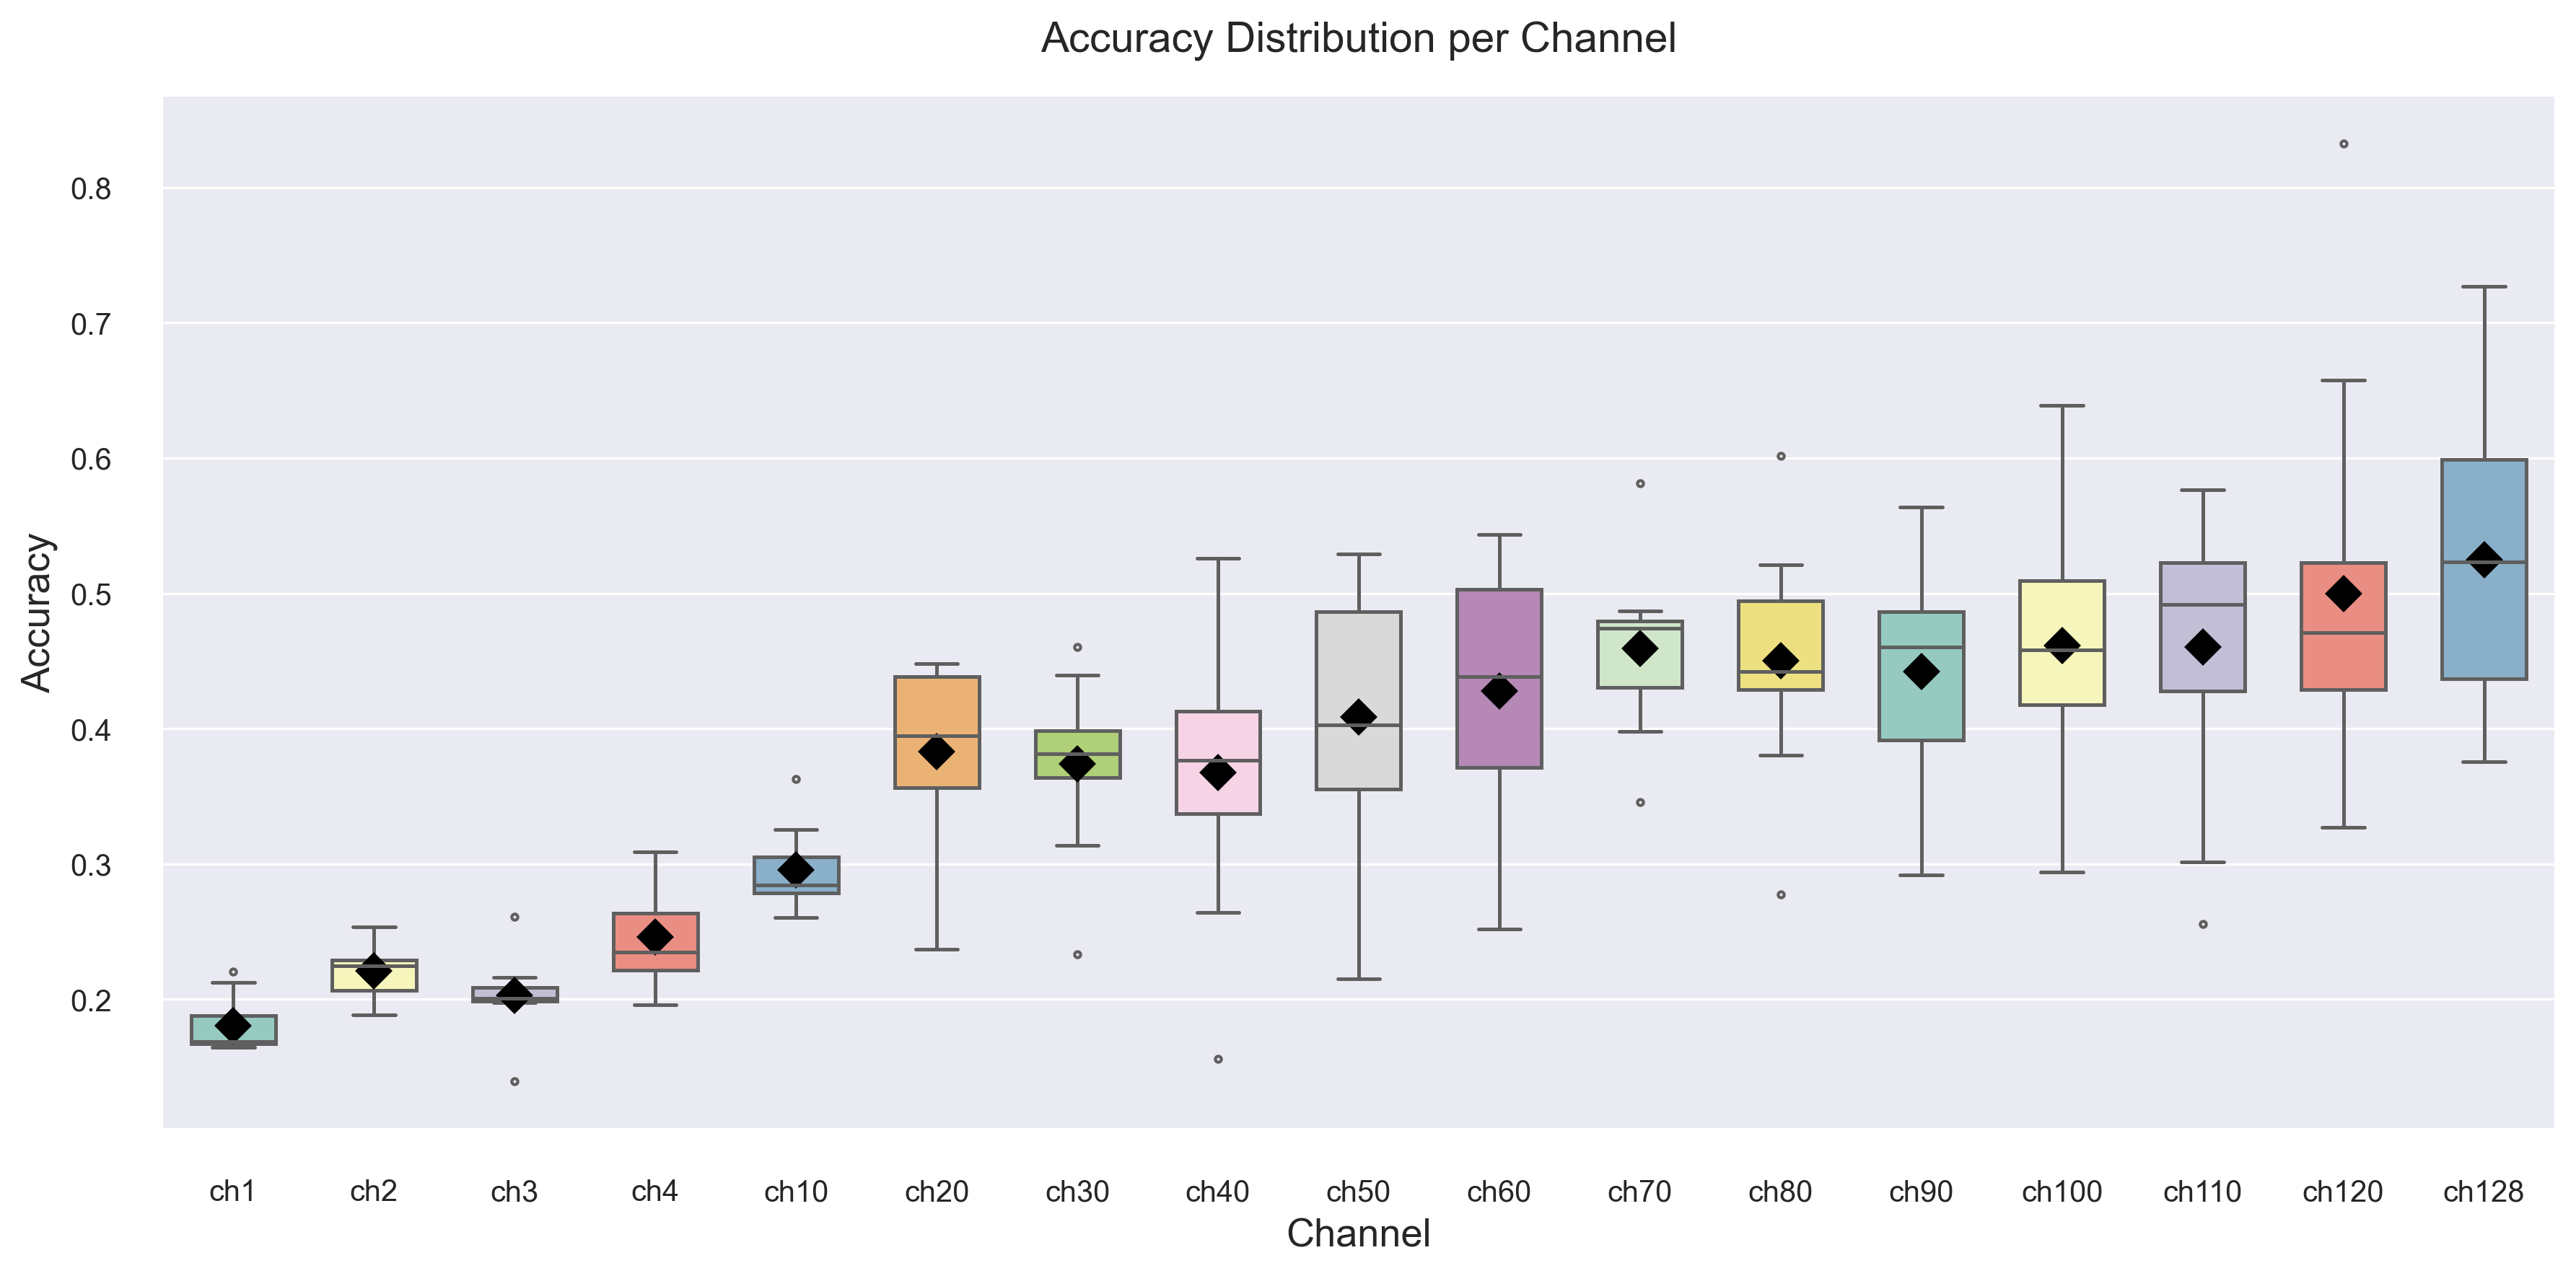

In [41]:
import seaborn as sns

data = {"ch1": [0.16787501, 0.16725001, 0.2124375 , 0.1918125 , 0.1669375 ,0.16993751, 0.2204375 , 0.1665    , 0.1646875 , 0.17524999],
    "ch2": [0.18862499, 0.2230625 , 0.226375  , 0.2291875 , 0.208625  , 0.2060625 , 0.24662501, 0.201125  , 0.2278125 , 0.2533125 ],
    "ch3": [0.1985625 , 0.139625  , 0.197375  , 0.19868749, 0.2163125 , 0.2084375 , 0.20900001, 0.2003125 , 0.20118751, 0.2610625 ],
    "ch4": [0.19562501, 0.30899999, 0.2296875 , 0.205625  , 0.218375  ,0.2349375 , 0.3084375 , 0.26449999, 0.26118749, 0.2344375 ],
    "ch10": [0.2813125 , 0.30781251, 0.3251875 , 0.26018751, 0.27849999, 0.2878125 , 0.36256251, 0.2968125 , 0.27862501, 0.27456251],
    "ch20": [0.2366875 , 0.40599999, 0.35468751, 0.44150811 , 0.36125001, 0.32574999, 0.4478125 , 0.38350001, 0.42981249, 0.44549999],
    "ch30": [0.372125  , 0.39737499, 0.398875  , 0.31393749, 0.37631249, 0.23306251, 0.4395    , 0.36087501, 0.46017593, 0.38681251],
    "ch40": [0.32506251, 0.45093751, 0.4131875 , 0.15575001, 0.376625  ,0.26425001, 0.5259375 , 0.3770625 , 0.4120625 , 0.37387499],
    "ch50": [0.34674999, 0.48800001, 0.42324999, 0.215     , 0.36618751,0.38249999, 0.52931249, 0.50325   , 0.48102725     , 0.35183205],
    "ch60": [0.36643749, 0.505     , 0.49625   , 0.32058415, 0.38550001, 0.252     , 0.53250003, 0.54337502, 0.46175   , 0.41549999],
    "ch70": [0.34575   , 0.4790625 , 0.48699999, 0.44762501, 0.39781249, 0.47180425     , 0.58112502, 0.47968751, 0.47631249, 0.42443749],
    "ch80": [0.38018751, 0.4433125 , 0.49931249, 0.44056249, 0.42868751,0.2775625 , 0.60175002, 0.52087498, 0.48006251, 0.428875  ],
    "ch90": [0.34258  , 0.4835628, 0.476625  , 0.29187925     , 0.39087501, 0.3926405, 0.5472915, 0.56393749, 0.4873125 , 0.44431251],
    "ch100": [0.39981249, 0.63912503, 0.48218751, 0.419125  , 0.29418751,0.416875  , 0.48101257, 0.52905384, 0.51831251, 0.43556249],
    "ch110": [0.523612501, 0.49524999, 0.52037501, 0.4683125 , 0.4140625 ,0.56240169, 0.30156249, 0.57656252, 0.48781249, 0.25543749],
    "ch120":  [0.83239017 , 0.48550001, 0.5160625 , 0.32690442, 0.42092518, 0.32689999, 0.65729105, 0.452065     , 0.45656249, 0.525     ],
    "ch128":  [0.51669105, 0.72683715 , 0.37529372, 0.46819505, 0.40762499, 0.42608175, 0.59044158, 0.605462, 0.5301852, 0.60191082],
}

data_ENG = {"ch1": [0.3000270575284958,  0.283676877617836,  0.28152263164520264,  0.3918125182390213,  0.29683414101600647,  0.32656437158584595,  0.29768769443035126,  0.32535669207572937,  0.230218306183815],
            "ch2": [0.35844360291957855,  0.42004814743995667,  0.3410288095474243,  0.4205674082040787,  0.4080287367105484,  0.4146491289138794,  0.41582389175891876,  0.46491244435310364,  0.25805988907814026],
            "ch3": [0.47221827507019043,  0.5444308817386627,  0.3897325098514557,  0.6488620638847351,  0.3686541020870209,  0.4439845234155655,  0.41395866870880127,  0.5134255588054657,  0.2570367380976677],
            "ch4": [0.4769471287727356,  0.5323783755302429,  0.40798354148864746,  0.688984751701355,  0.4184621274471283,  0.4882279634475708,  0.4483221024274826,  0.559606513977051,  0.2804621160030365, 0.7251902371163402]}


df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data.items()]))
df_melted = df.melt(var_name="Channel", value_name="Accuracy")

# 시각화
plt.figure(figsize=(12,6), dpi=300)

# 박스플롯 (내부 평균선 제거, 깔끔한 스타일)
sns.boxplot(
    x="Channel", y="Accuracy", data=df_melted,
    palette="Set3",  # 색상 팔레트 (깔끔한 톤)
    width=0.6,
    fliersize=2,     # outlier 점 크기
    linewidth=1.2
)

# 각 채널 평균점 찍어주기 (논문용이면 강조)
sns.pointplot(x="Channel", y="Accuracy", data=df_melted, estimator="mean", color="black", markers="D",  # 다이아몬드 모양
    ci=None, join=False)

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel("Accuracy", fontsize=13)
plt.xlabel("Channel", fontsize=13)
plt.title("Accuracy Distribution per Channel", fontsize=14, pad=15)

sns.despine(offset=10, trim=True)  # 위/오른쪽 테두리 제거
plt.tight_layout()
plt.show()


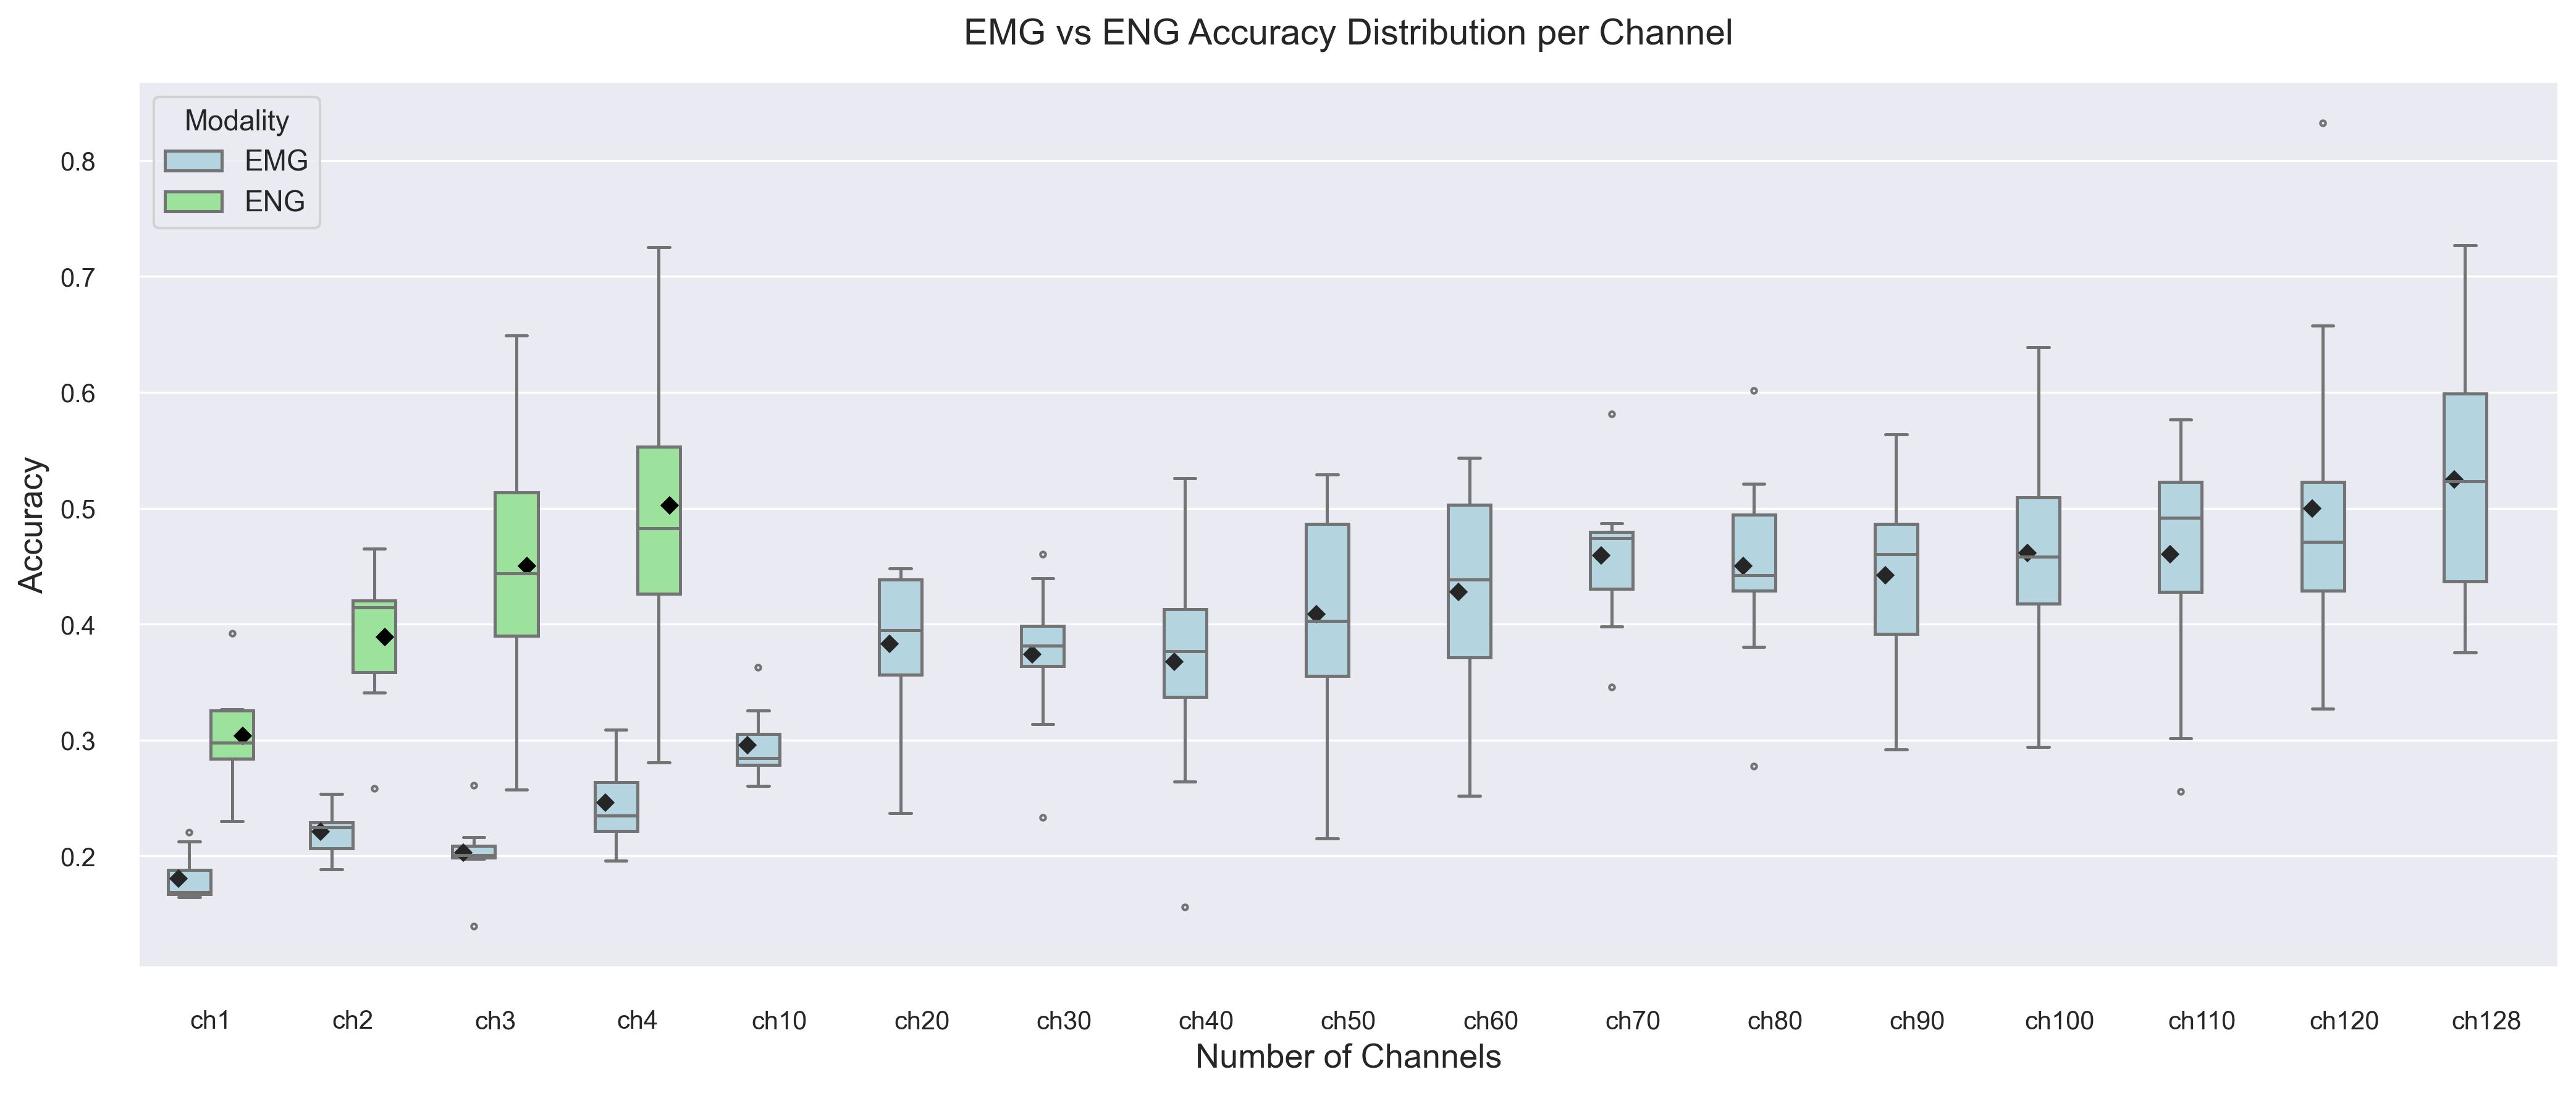

In [42]:
df_emg = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data.items()]))
df_emg = df_emg.melt(var_name="Channel", value_name="Accuracy")
df_emg["Modality"] = "EMG"

df_eng = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_ENG.items()]))
df_eng = df_eng.melt(var_name="Channel", value_name="Accuracy")
df_eng["Modality"] = "ENG"

df_all = pd.concat([df_emg, df_eng], ignore_index=True)

channels = sorted(df_all["Channel"].unique(), key=lambda x: int(x[2:]))  # "ch1"→1 기준 정렬
df_all["Channel"] = pd.Categorical(df_all["Channel"], categories=channels, ordered=True)

plt.figure(figsize=(14,6), dpi=300)

palette = {"EMG": "lightblue", "ENG": "lightgreen"}
palette2 = {"EMG": "blue", "ENG": "red"}

sns.boxplot(
    x="Channel", y="Accuracy", hue="Modality", data=df_all,
    width=0.6, fliersize=2, linewidth=1.2,
    palette=palette
)

sns.pointplot(
    x="Channel", y="Accuracy", hue="Modality", data=df_all,
    estimator=np.mean, dodge=0.45, join=False, ci=None,
    markers="D", scale=0.7, color='black', #palette=palette2
)

# -------------------------
# Labeling & Style
# -------------------------
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel("Accuracy", fontsize=13)
plt.xlabel("Number of Channels", fontsize=13)
plt.title("EMG vs ENG Accuracy Distribution per Channel", fontsize=14, pad=15)

# 범례 정리 (겹치지 않게 한 줄만 남기기)
handles, labels = plt.gca().get_legend_handles_labels()
n = int(len(handles)/2)  # boxplot + pointplot 중복 제거
plt.legend(handles[:n], labels[:n], title="Modality", fontsize=11, title_fontsize=11, loc="upper left")

sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

In [ ]:
acc_lst_ch4 = [0.2697368487715721, 0.27960526943206787, 0.2697368413209915, 0.25986841320991516, 0.32236842811107635,0.30921052396297455, 0.23026316612958908, 0.33552631735801697, 0.32236842811107635]
acc_lst_ch3 = [0.30592105, 0.23355263, 0.21381579, 0.34539473, 0.22039474, 0.25      , 0.21381579, 0.25986843, 0.27631579]
acc_lst_ch2 = [0.24342105, 0.15131579, 0.25      , 0.20723684, 0.25986842, 0.26315789, 0.2993421 , 0.23026316, 0.25]
acc_lst_ch1 = [0.125     , 0.125     , 0.19078948, 0.125     , 0.15789474,        0.13486842, 0.21710526, 0.16776316, 0.15460526]

accs = [float(v) for v in [np.mean(acc_lst_ch1), np.mean(acc_lst_ch2), np.mean(acc_lst_ch3), np.mean(acc_lst_ch4)]]
stds = [float(v) for v in [np.std(acc_lst_ch1), np.std(acc_lst_ch2), np.std(acc_lst_ch3), np.std(acc_lst_ch4)]]

accs, stds

In [ ]:
import matplotlib.pyplot as plt

capgmyo_A = [0.15533625777777782,0.23940058333333333,  0.2576754388888889,  0.28874269293414223]
capgmyo_A_std = [0.03057531081066181,  0.03900728778730371,  0.042495222353503705,  0.033214012863790277]
eng_ours = [0.20592691832118565,  0.22991960992415747, 0.25636376980278227, 0.28052006037367714]
eng_ours_std = [0.05375169177908187, 0.08492193274795812, 0.08343234445005425, 0.09487073400413076]

x_label = [f'{i}-Channel' for i in range(1,5)]
x = range(len(x_label))

#plt.errorbar(x, capgmyo, yerr=capgmyo_std, fmt='o-', capsize=5, label="Capgmyo")
#plt.errorbar(x, eng_ours, yerr=eng_ours_std, fmt='o-', capsize=5, label="ENG Ours")
plt.plot(x, capgmyo_A, marker='o', label="Capgmyo-DB A")
plt.plot(x, eng_ours, marker='o', label="ENG")

plt.xticks(x, x_label)
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


anp.array(acc_lst_ch3)atotal 10 sessions - training on 9 / testing on 1

ours: